# Assignment: Hypothesis Testing using Language Models
## Questions 1: Computing Language Model Scores

---

In [2]:
import subprocess
import os

NGRAM_BIN = "../ngram"
NGRAM_COUNT_BIN = "../ngram-count"
BROWN_TRAIN = "../browndata/brown-train.txt"
BROWN_DEV = "../browndata/brown-dev.txt"
BROWN_TEST = "../browndata/brown-test.txt"
BNC_CSV = "../bnc.csv"
MODELS_DIR = "../models"

os.makedirs(MODELS_DIR, exist_ok=True)

for b in [NGRAM_BIN, NGRAM_COUNT_BIN]:
    if os.path.exists(b):
        os.chmod(b, 0o755)
        print(f"{b} is executable")
    else:
        print(f"NOT FOUND: {b}")

../ngram is executable
../ngram-count is executable


In [3]:
def run_cmd(cmd, desc=""):
    print(f"\nRunning: {desc}")
    # NOTE: Running on WSL, remove the below command if running on Linux/Mac
    wsl_cmd = ["wsl"] + cmd
    print(f"CMD: {' '.join(wsl_cmd)}")
    result = subprocess.run(wsl_cmd, capture_output=True, text=True)
    if result.stdout.strip():
        print(result.stdout.strip()[:400])
    if result.returncode != 0:
        print("STDERR:", result.stderr[:2000])
        raise RuntimeError(f"Command failed (exit {result.returncode})")
    return result


run_cmd(
    [
        NGRAM_COUNT_BIN,
        "-order",
        "1",
        "-text",
        BROWN_TRAIN,
        "-lm",
        f"{MODELS_DIR}/unigram.lm",
    ],
    "Unigram LM (Good-Turing)",
)

run_cmd(
    [
        NGRAM_COUNT_BIN,
        "-order",
        "2",
        "-text",
        BROWN_TRAIN,
        "-lm",
        f"{MODELS_DIR}/bigram.lm",
        "-kndiscount2",
        "-interpolate",
    ],
    "Bigram LM (Kneser-Ney, order 2)",
)

run_cmd(
    [
        NGRAM_COUNT_BIN,
        "-order",
        "3",
        "-text",
        BROWN_TRAIN,
        "-lm",
        f"{MODELS_DIR}/trigram.lm",
        "-kndiscount2",
        "-kndiscount3",
        "-interpolate",
    ],
    "Trigram LM (Kneser-Ney, orders 2 and 3)",
)

print("\nAll three models trained.")


Running: Unigram LM (Good-Turing)
CMD: wsl ../ngram-count -order 1 -text ../browndata/brown-train.txt -lm ../models/unigram.lm

Running: Bigram LM (Kneser-Ney, order 2)
CMD: wsl ../ngram-count -order 2 -text ../browndata/brown-train.txt -lm ../models/bigram.lm -kndiscount2 -interpolate

Running: Trigram LM (Kneser-Ney, orders 2 and 3)
CMD: wsl ../ngram-count -order 3 -text ../browndata/brown-train.txt -lm ../models/trigram.lm -kndiscount2 -kndiscount3 -interpolate

All three models trained.


In [4]:
import pandas as pd
import numpy as np
import tempfile, re

bnc = pd.read_csv(BNC_CSV, sep="\t")
print(f"BNC dataset: {len(bnc)} rows")
print(bnc.head(3))

BNC dataset: 5250 rows
    MOP language                                               text  length  \
0  MOP2       en  We've still got the Dower House , and Lincolns...      12   
1  MOP2       en  My first real friend was probably a boy called...      10   
2  MOP2       en  She was wearing denim overalls and carrying a ...      11   

                             rating_list  mean_rating  
0  4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4          4.0  
1           4, 4, 4, 4, 4, 4, 4, 4, 4, 4          4.0  
2     4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4          4.0  


In [5]:
def to_wsl_path(win_path):
    win_path = os.path.abspath(win_path)
    match = re.match(r'^([a-zA-Z]):(.*)', win_path)
    if match:
        drive, path = match.groups()
        # Create /mnt/c/... format and fix slashes
        return f"/mnt/{drive.lower()}{path.replace('\\', '/')}"
    return win_path.replace('\\', '/')

def score_sentences_srilm(sentences, lm_path, ngram_bin, order):
    with tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False, encoding="utf-8") as f:
        for s in sentences:
            f.write(s.strip() + "\n")
        tmp_path = f.name

    # --- NOTE: Converting Windows path to WSL path ---
    wsl_tmp_path = to_wsl_path(tmp_path)
    wsl_lm_path = to_wsl_path(lm_path)
    wsl_ngram_bin = to_wsl_path(ngram_bin)

    # NOTE: Running on WSL, remove the "wsl" from the below command if running on Linux/Mac
    cmd = [
        "wsl",
        wsl_ngram_bin,
        "-order",
        str(order),
        "-lm",
        wsl_lm_path,
        "-ppl",
        wsl_tmp_path,
        "-debug",
        "2",
    ]
    result = subprocess.run(
        cmd,
        capture_output=True,
        encoding="utf-8",
        errors="replace",
    )

    if os.path.exists(tmp_path):
        os.unlink(tmp_path)

    if result.returncode != 0:
        raise RuntimeError(result.stderr[:1000])

    logprobs, nwords = [], []
    for line in result.stdout.splitlines():
        m = re.search(r"logprob=\s*([\-\d\.]+)", line)
        if m:
            logprobs.append(float(m.group(1)) * np.log(10))
        m2 = re.search(r"(\d+) words", line)
        if m2 and "OOV" in line:
            nwords.append(int(m2.group(1)))

    logprobs = logprobs[:len(sentences)]
    nwords = nwords[:len(sentences)]

    if len(logprobs) != len(sentences):
        raise ValueError(f"Expected {len(sentences)} log-probs, got {len(logprobs)}")

    return list(zip(logprobs, nwords))

In [6]:
sentences = bnc["text"].tolist()
n_words = bnc["length"].tolist()

print("Scoring with Unigram model...")
uni_scores = score_sentences_srilm(
    sentences, f"{MODELS_DIR}/unigram.lm", NGRAM_BIN, order=1
)

print("Scoring with Bigram model...")
bi_scores = score_sentences_srilm(
    sentences, f"{MODELS_DIR}/bigram.lm", NGRAM_BIN, order=2
)

print("Scoring with Trigram model...")
tri_scores = score_sentences_srilm(
    sentences, f"{MODELS_DIR}/trigram.lm", NGRAM_BIN, order=3
)

print("\nScoring complete.")

Scoring with Unigram model...
Scoring with Bigram model...
Scoring with Trigram model...

Scoring complete.


In [8]:
scored = bnc.copy()
scored["uni_logprob"] = [lp for lp, _ in uni_scores]

for model_name, raw_scores in [("bigram", bi_scores), ("trigram", tri_scores)]:
    logprobs = np.array([lp for lp, _ in raw_scores])
    word_lens = scored["length"].values

    scored[f"{model_name}_log_prob"] = logprobs
    scored[f"{model_name}_mean_log_prob"] = logprobs / word_lens
    scored[f"{model_name}_slor"] = logprobs - scored["uni_logprob"].values

scored[
        [
            "text",
            "mean_rating",
            "bigram_log_prob",
            "bigram_mean_log_prob",
            "bigram_slor",
            "trigram_log_prob",
            "trigram_mean_log_prob",
            "trigram_slor",
        ]
    ].to_csv("./scored_bnc.csv", index=False)

print(
    scored[
        [
            "text",
            "mean_rating",
            "bigram_log_prob",
            "bigram_mean_log_prob",
            "bigram_slor",
            "trigram_log_prob",
            "trigram_mean_log_prob",
            "trigram_slor",
        ]
    ].head(5)
)

                                                text  mean_rating  \
0  We've still got the Dower House , and Lincolns...     4.000000   
1  My first real friend was probably a boy called...     4.000000   
2  She was wearing denim overalls and carrying a ...     4.000000   
3  In the next year he had custody of Rochester C...     3.812500   
4  BOOKING is essential for a cycle ride around W...     3.076923   

   bigram_log_prob  bigram_mean_log_prob  bigram_slor  trigram_log_prob  \
0       -75.012696             -6.251058     5.366635        -74.651421   
1       -75.253777             -7.525378     8.322694        -74.569448   
2       -64.525112             -5.865919    18.809357        -60.955644   
3       -42.554536             -4.255454    16.364703        -41.996389   
4      -135.186152             -6.144825    19.207014       -135.757424   

   trigram_mean_log_prob  trigram_slor  
0              -6.220952      5.727911  
1              -7.456945      9.007022  
2          

## Question 2: Spearman Correlation

---

In [ ]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

human_ratings = scored["mean_rating"].values

score_cols = [
    ("bigram", "log_prob", "Bigram  — log P"),
    ("bigram", "mean_log_prob", "Bigram  — mean log P"),
    ("bigram", "slor", "Bigram  — SLOR"),
    ("trigram", "log_prob", "Trigram — log P"),
    ("trigram", "mean_log_prob", "Trigram — mean log P"),
    ("trigram", "slor", "Trigram — SLOR"),
]

results = []
for model, score, label in score_cols:
    col = f"{model}_{score}"
    rho, pval = spearmanr(scored[col].values, human_ratings)
    results.append(
        {
            "Model": model.capitalize(),
            "Score": score,
            "Label": label,
            "Spearman": rho,
            "p-value": pval,
        }
    )

results_df = pd.DataFrame(results)
print(results_df[["Label", "Spearman", "p-value"]].to_string(index=False))

               Label  Spearman      p-value
     Bigram  — log P  0.134447 1.322530e-22
Bigram  — mean log P  0.071727 1.965746e-07
      Bigram  — SLOR  0.043532 1.605176e-03
     Trigram — log P  0.136813 2.338483e-23
Trigram — mean log P  0.076259 3.161471e-08
      Trigram — SLOR  0.052788 1.299035e-04


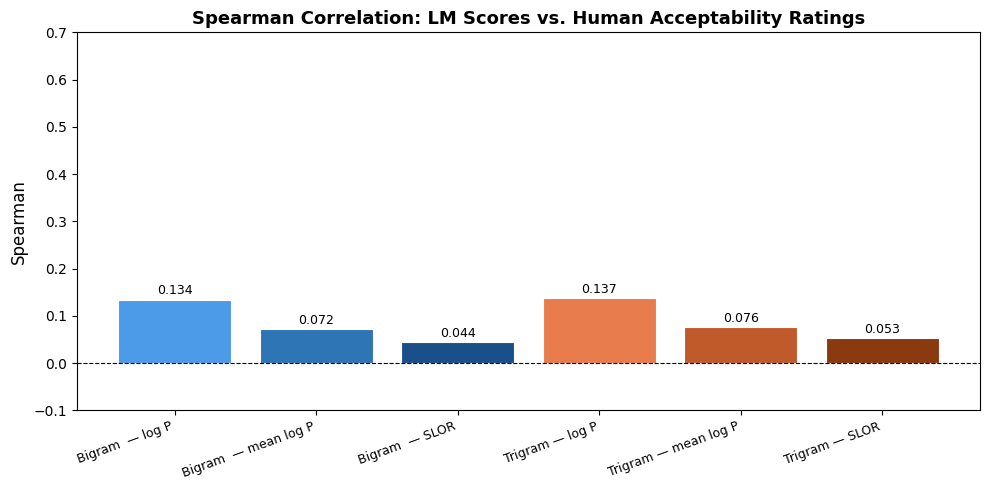

Figure saved as spearman_correlations.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#4C9BE8", "#2E75B6", "#1B4F8A", "#E87C4C", "#C05A2B", "#8B3A10"]

bars = ax.bar(
    results_df["Label"],
    results_df["Spearman"],
    color=colors,
    edgecolor="white",
    linewidth=0.8,
)

for bar, row in zip(bars, results_df.itertuples()):
    sig = "*" if getattr(row, 'p-value', float('inf')) < 0.05 else ""
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{row.Spearman:.3f}{sig}",
        ha="center",    
        va="bottom",
        fontsize=9,
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Spearman", fontsize=12)
ax.set_title(
    "Spearman Correlation: LM Scores vs. Human Acceptability Ratings",
    fontsize=13,
    fontweight="bold",
)
ax.set_ylim(-0.1, 0.7)
plt.xticks(rotation=20, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("spearman_correlations.png", dpi=150)
plt.show()
print("Figure saved as spearman_correlations.png")

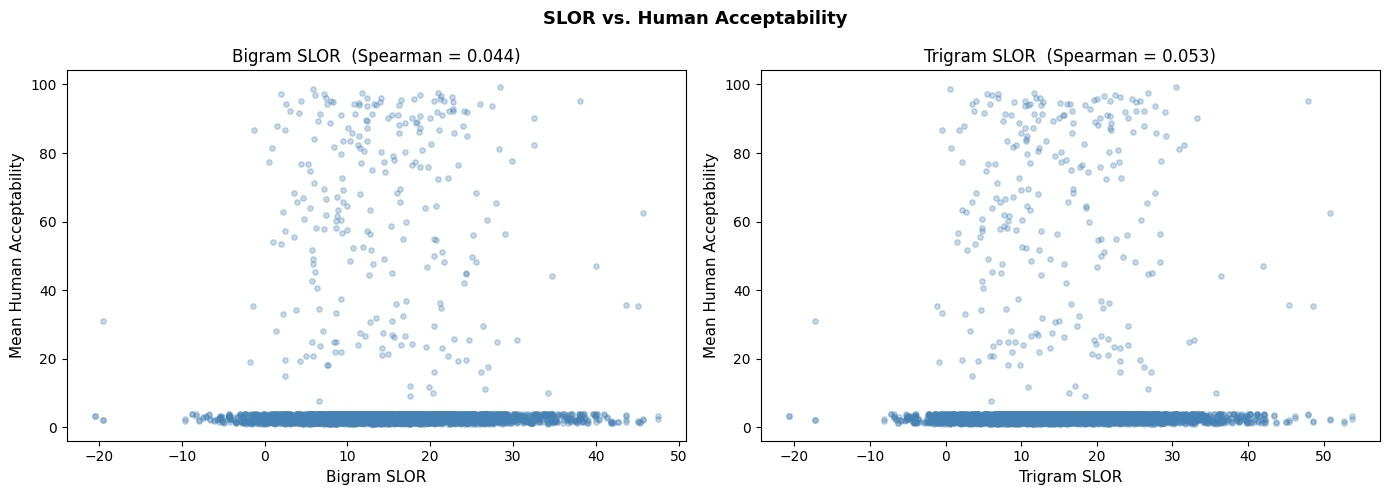

In [ ]:
best_row = results_df.loc[results_df["Spearman"].idxmax()]
best_col = f"{best_row['Model'].lower()}_{best_row['Score']}"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model, score, label) in zip(
    axes, [("bigram", "slor", "Bigram SLOR"), ("trigram", "slor", "Trigram SLOR")]
):
    col = f"{model}_{score}"
    rho, _ = spearmanr(scored[col], human_ratings)
    ax.scatter(scored[col], human_ratings, alpha=0.3, s=15, color="steelblue")
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Mean Human Acceptability", fontsize=11)
    ax.set_title(f"{label}  (Spearman = {rho:.3f})", fontsize=12)

plt.suptitle("SLOR vs. Human Acceptability", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("slor_scatter.png", dpi=150)
plt.show()